In [1]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"data/data.csv")


In [3]:
df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,temp_avg,rainy_day,windy_day,nice_temp,freeze_day,score
0,2020-04-17,14.2,3.3,0.0,19.0,8.8,False,False,False,False,2
1,2020-04-18,12.0,0.7,0.0,10.3,6.4,False,False,False,False,2
2,2020-04-19,12.1,1.0,0.0,22.5,6.6,False,True,False,False,1
3,2020-04-20,13.2,1.5,0.0,16.3,7.4,False,False,False,False,2
4,2020-04-21,15.8,4.1,0.0,20.5,10.0,False,True,False,False,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                2192 non-null   object 
 1   temperature_2m_max  2192 non-null   float64
 2   temperature_2m_min  2192 non-null   float64
 3   precipitation_sum   2192 non-null   float64
 4   windspeed_10m_max   2192 non-null   float64
 5   temp_avg            2192 non-null   float64
 6   rainy_day           2192 non-null   bool   
 7   windy_day           2192 non-null   bool   
 8   nice_temp           2192 non-null   bool   
 9   freeze_day          2192 non-null   bool   
 10  score               2192 non-null   int64  
dtypes: bool(4), float64(5), int64(1), object(1)
memory usage: 128.6+ KB


In [5]:
df["time"] = pd.to_datetime(df["time"])

In [6]:
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day

Rozkład maksymalnej temperatury

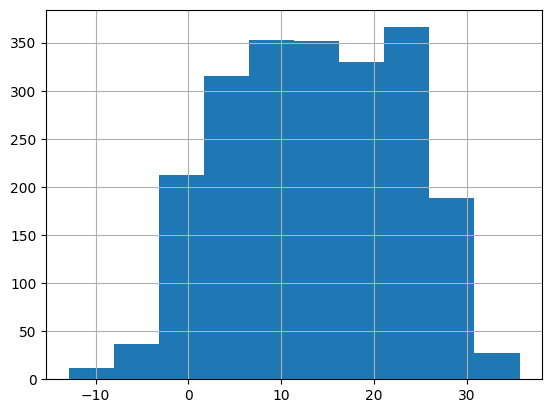

In [28]:
df["temperature_2m_max"].hist()
plt.show()

In [7]:
Macierz korelacji

SyntaxError: invalid syntax (2624577640.py, line 1)

<Axes: >

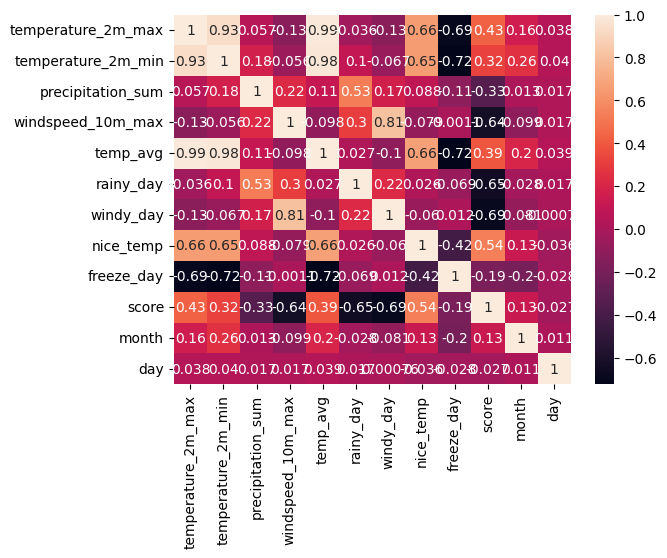

In [31]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

Rozkład score

In [32]:
df["score"].value_counts()

score
2    863
1    683
0    336
3    310
Name: count, dtype: int64

Średnia temperatura w czasie

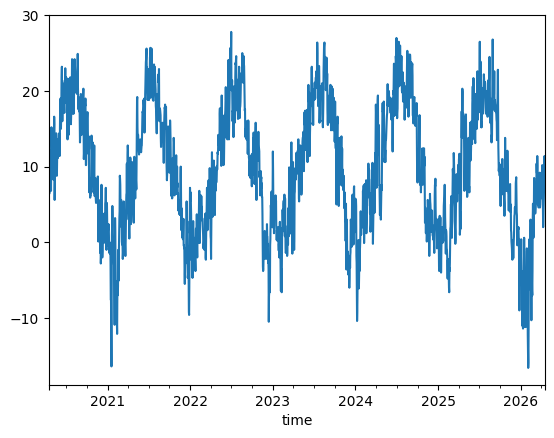

In [10]:
df.set_index("time")["temp_avg"].plot()
plt.show()

Średnia temperatura w podziale na miesiące

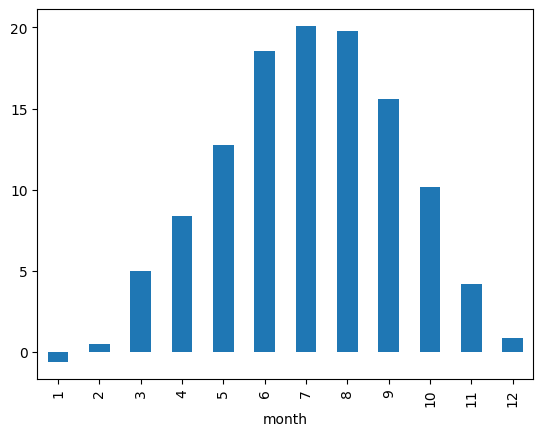

In [35]:
df.groupby("month")["temp_avg"].mean().plot(kind="bar")
plt.show()

Procent dni deszczowych

In [15]:
print(f'{round((float(df["rainy_day"].mean())*100),2)}%')


44.11%


Procent dni wietrznych

In [16]:
print(f'{round((float(df["windy_day"].mean())*100),2)}%')

39.28%


Procent dni mroźnych

In [17]:
print(f'{round((float(df["freeze_day"].mean())*100),2)}%')

24.09%


Rozkład ocen dni

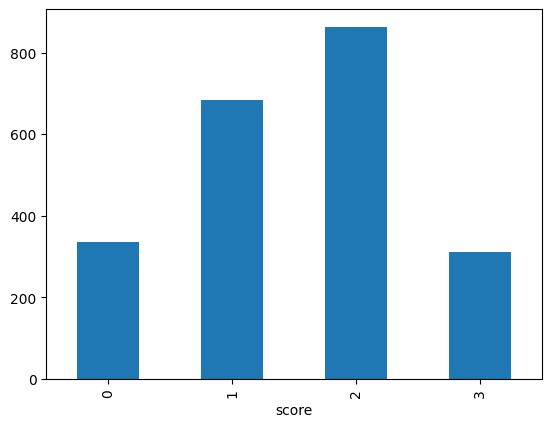

In [45]:
df["score"].value_counts().sort_index().plot(kind="bar")
plt.show()

Najlepsze miesiące pod względem oceny

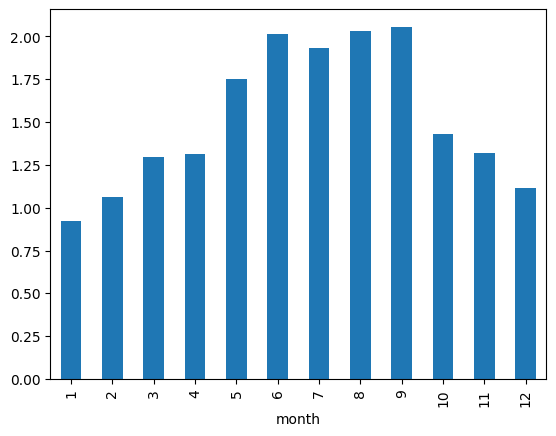

In [20]:
df.groupby("month")["score"].mean().plot(kind="bar")
plt.show()

Najbardziej wietrzne miesiące

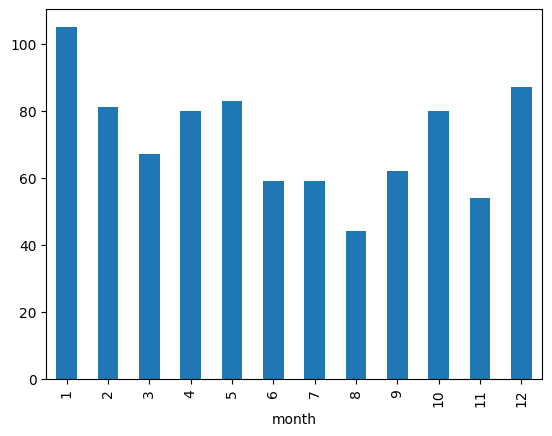

In [22]:
df.groupby("month")["windy_day"].sum().plot(kind="bar")
plt.show()

Najbardziej deszczowe dni

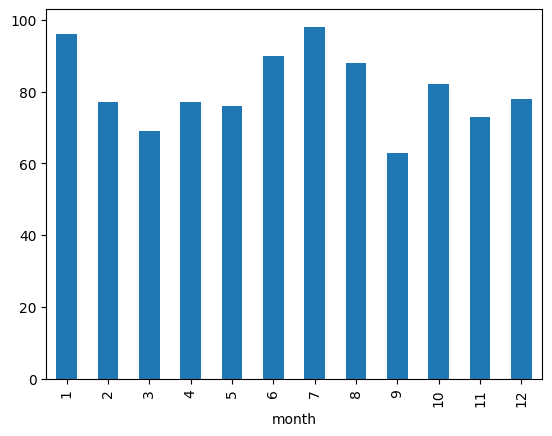

In [27]:
df.groupby("month")["rainy_day"].sum().plot(kind="bar")
plt.show()

Czy częstość opadów = suma deszczu?

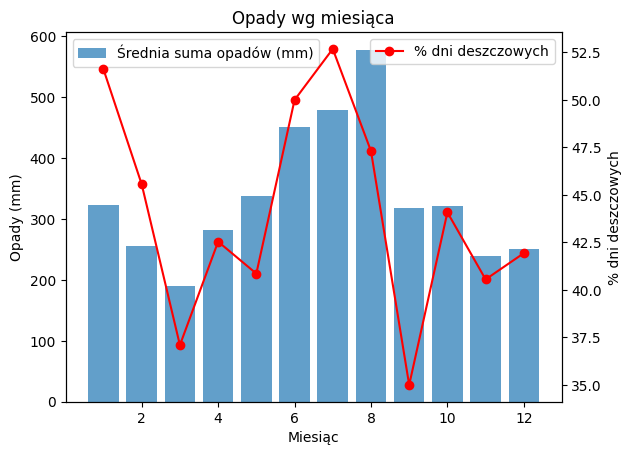

In [ ]:
rain_sum = df.groupby("month")["precipitation_sum"].sum()
rainy_days = df.groupby("month")["rainy_day"].mean() * 100

fig, ax1 = plt.subplots()

ax1.bar(rain_sum.index, rain_sum, label="Średnia suma opadów (mm)", alpha=0.7)
ax1.set_xlabel("Miesiąc")
ax1.set_ylabel("Opady (mm)")

ax2 = ax1.twinx()
ax2.plot(rainy_days.index, rainy_days, color="red", marker="o", label="% dni deszczowych")
ax2.set_ylabel("% dni deszczowych")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Opady wg miesiąca")
plt.show()

Maksymalna temperatura

In [25]:
max_temp = df["temperature_2m_max"].max()

row_max = df[df["temperature_2m_max"] == max_temp]

print(row_max[["time", "temperature_2m_max"]])

           time  temperature_2m_max
1903 2025-07-03                35.7


Minimalna temperatura

In [26]:
min_temp = df["temperature_2m_min"].min()

row_min = df[df["temperature_2m_min"] == min_temp]

print(row_min[["time", "temperature_2m_min"]])

           time  temperature_2m_min
2118 2026-02-03               -21.7
